# Dynamic Facial Expression Recognition with Images

In [1]:
name_of_this_notebook = 'late_fusion_cross_attention.ipynb'

In [2]:
# import os

# os.environ['PYTHONHASHSEED'] = '7'

In [3]:
!echo "${PYTHONUNBUFFERED}"
!echo "${TF_CPP_MIN_LOG_LEVEL}"
!echo "${TF_FORCE_GPU_ALLOW_GROWTH}"
!echo "${TF_GPU_ALLOCATOR}"
!echo "${PYTHONHASHSEED}"


2
true
cuda_malloc_async



In [4]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')

Notebook log filter installed (targeted, keeps Keras steps).


In [5]:
import keras

keras.mixed_precision.set_global_policy('mixed_float16')

2025-11-24 19:22:37.189037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-24 19:22:37.197805: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-24 19:22:37.200694: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
# Ensure Determinism
import random
import numpy as np
import tensorflow as tf

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
# tf.config.experimental.enable_op_determinism()

In [7]:
# Ensure GPU works as expected
import json

print('TensorFlow Version:', tf.__version__, ';', 'Keras Version:', keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Number of GPUs detected: {len(gpus)}')
    for gpu in gpus:
        device_details = tf.config.experimental.get_device_details(gpu)
        print(f'Physical Device: {gpu.name}')
        print(f'Name: {device_details["device_name"]}')
        print(f'Compute Capability: {device_details["compute_capability"]}')
else:
    print('No GPUs were detected.')

print(json.dumps(tf.sysconfig.get_build_info(), indent=2))

TensorFlow Version: 2.17.0 ; Keras Version: 3.12.0
Number of GPUs detected: 1
Physical Device: /physical_device:GPU:0
Name: NVIDIA GeForce RTX 5090
Compute Capability: (12, 0)
{
  "cpu_compiler": "/opt/rh/gcc-toolset-11/root/usr/bin/gcc",
  "cuda_compute_capabilities": [
    "sm_100",
    "sm_120",
    "sm_75",
    "sm_80",
    "sm_86",
    "compute_90"
  ],
  "cuda_version": "12.8",
  "cudnn_version": "9",
  "is_cuda_build": true,
  "is_rocm_build": false,
  "is_tensorrt_build": true
}


In [8]:
from keras import layers
from keras.saving import register_keras_serializable

@register_keras_serializable(package="seqaug")
class SequenceAugment(layers.Layer):
    """
    Efficient, sequence-consistent video augmentation for inputs shaped (B, T, H, W, C).
    Compatible with Keras 3.12.0 / TF 2.17.0.

    Key design choices:
    - Works in float32 [0..255] space (EfficientNetV2 handles rescaling internally).
    - Applies exactly ONE tf.map_fn over sequences (B dimension). Inside, all ops are vectorized over T frames.
    - Random parameters are sampled ONCE per sequence so all frames get the same transform (no artificial motion).
    - Positive rotation angles are COUNTER-CLOCKWISE (CCW) visually.

    Inference gating:
      Augmentations apply only when `training is True`. Evaluation/predict paths pass inputs through (casted to float32).
    """

    def __init__(
        self,
        image_size=(224, 224),         # Target (H, W) after spatial augs
        crop_scale=(0.90, 1.0),        # RandomResizedCrop: sampled scale ∈ [min,max] of original size
        rotation_max_deg=30.0,         # Uniform |angle| ∈ [0,max], random sign; positive = CCW
        fill_mode="CONSTANT",          # Rotation fill: "CONSTANT", "REFLECT", or "WRAP"
        fill_value=1.0,                # Used when fill_mode == "CONSTANT"
        flip_prob=0.5,                 # Probability to flip the whole sequence horizontally
        brightness_max_delta=20.0,     # Additive brightness jitter in 0..255 domain (sequence-consistent)
        contrast_lower=0.9, contrast_upper=1.1,  # Contrast factor range (sequence-consistent)
        gamma_range=None,              # Optional gamma jitter e.g. (0.95, 1.05); None disables
        clip_after_color=True,         # Clip to [0,255] after color ops to avoid blowouts
        noise_std=0,                   # Gaussian noise std in 0..255 domain (0 disables)
        temporal_shift_max=2,          # Roll by [-k,+k] frames
        frame_drop_prob=0.10,          # Per-frame prob to replace with previous frame
        time_mask_prob=0.10,           # Prob to mask a contiguous temporal block
        time_mask_max_frac=0.20,       # Max fraction of T for temporal block mask
        invert_prob=0.00,              # Prob to invert whole sequence (x -> 255-x).
        solarize_prob=0.05,            # Prob to solarize (> threshold).
        solarize_threshold=(120.0, 160.0),  # Threshold uniform range used when solarizing
        **kwargs
    ):
        super().__init__(**kwargs)
        self.image_size = tuple(image_size)
        self.crop_scale = tuple(crop_scale)
        self.rotation_max_deg = float(rotation_max_deg)
        self.fill_mode = str(fill_mode).upper()
        self.fill_value = float(fill_value)
        self.flip_prob = float(flip_prob)
        self.brightness_max_delta = float(brightness_max_delta)
        self.contrast_lower = float(contrast_lower)
        self.contrast_upper = float(contrast_upper)
        self.gamma_range = None if gamma_range is None else tuple(gamma_range)
        self.clip_after_color = bool(clip_after_color)
        self.noise_std = float(noise_std)
        self.temporal_shift_max = int(temporal_shift_max)
        self.frame_drop_prob = float(frame_drop_prob)
        self.time_mask_prob = float(time_mask_prob)
        self.time_mask_max_frac = float(time_mask_max_frac)
        self.invert_prob = float(invert_prob)
        self.solarize_prob = float(solarize_prob)
        self.solarize_threshold = tuple(solarize_threshold)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "image_size": self.image_size,
            "crop_scale": self.crop_scale,
            "rotation_max_deg": self.rotation_max_deg,
            "fill_mode": self.fill_mode,
            "fill_value": self.fill_value,
            "flip_prob": self.flip_prob,
            "brightness_max_delta": self.brightness_max_delta,
            "contrast_lower": self.contrast_lower,
            "contrast_upper": self.contrast_upper,
            "gamma_range": self.gamma_range,
            "clip_after_color": self.clip_after_color,
            "noise_std": self.noise_std,
            "temporal_shift_max": self.temporal_shift_max,
            "frame_drop_prob": self.frame_drop_prob,
            "time_mask_prob": self.time_mask_prob,
            "time_mask_max_frac": self.time_mask_max_frac,
            "invert_prob": self.invert_prob,
            "solarize_prob": self.solarize_prob,
            "solarize_threshold": self.solarize_threshold,
        })
        return cfg

    # ---------------------------------------------------------------------
    # Spatial / photometric (sequence-consistent across T frames)
    # ---------------------------------------------------------------------

    def _random_resized_crop_sequence(self, seq):
        """
        RandomResizedCrop for the entire sequence (same crop on all frames).
        Usage:
          - Keeps face alignment stable; avoids artificial motion from per-frame crops.
          - For tightly cropped face inputs, prefer scale in ~[0.95, 1.0].
        Input:
          seq: float32 (T, H, W, C) in [0..255]
        Output:
          cropped-resized seq: float32 (T, image_size[0], image_size[1], C)
        """
        t, h, w, c = tf.unstack(tf.shape(seq))
        s = tf.random.uniform([], self.crop_scale[0], self.crop_scale[1])
        nh = tf.maximum(1, tf.cast(s * tf.cast(h, tf.float32), tf.int32))
        nw = tf.maximum(1, tf.cast(s * tf.cast(w, tf.float32), tf.int32))

        # Top-left corner for ALL frames in the sequence
        my = tf.maximum(1, h - nh + 1)
        mx = tf.maximum(1, w - nw + 1)
        y0 = tf.random.uniform([], 0, my, dtype=tf.int32)
        x0 = tf.random.uniform([], 0, mx, dtype=tf.int32)

        # Normalized boxes for tf.image.crop_and_resize
        h_f = tf.cast(h, tf.float32); w_f = tf.cast(w, tf.float32)
        y1 = tf.cast(y0, tf.float32) / h_f
        x1 = tf.cast(x0, tf.float32) / w_f
        y2 = tf.cast(y0 + nh, tf.float32) / h_f
        x2 = tf.cast(x0 + nw, tf.float32) / w_f
        box = tf.stack([y1, x1, y2, x2], axis=0)              # (4,)
        boxes = tf.repeat(tf.expand_dims(box, 0), t, axis=0)  # (T,4)
        idx = tf.range(t, dtype=tf.int32)                     # (T,)

        # Single kernel applying identical crop to each frame
        cropped = tf.image.crop_and_resize(
            seq, boxes=boxes, box_indices=idx,
            crop_size=self.image_size, method="bilinear"
        )
        return cropped

    def _random_rotate_sequence(self, seq):
        """
        Random rotation with a single angle for the whole sequence.
        Usage:
          - Angle magnitude sampled uniformly from [0, rotation_max_deg], sign random (±).
          - Positive angles rotate CCW visually. We use inverse mapping for output->input transform.
          - Choose mild ranges (e.g., 5–8 degrees) for faces to preserve landmarks.
        Input:
          seq: float32 (T, H, W, C)
        Output:
          rotated seq: float32 (T, H, W, C)
        """
        if self.rotation_max_deg <= 0.0:
            return seq

        PI = tf.constant(np.pi, dtype=tf.float32)
        mag = tf.random.uniform([], 0.0, self.rotation_max_deg)   # [0,max]
        sgn = tf.where(tf.random.uniform([]) < 0.5, -1.0, 1.0)    # choose direction
        ang = (mag * sgn) * (PI / 180.0)

        h = tf.cast(self.image_size[0], tf.float32)
        w = tf.cast(self.image_size[1], tf.float32)
        cx = (w - 1.0) * 0.5
        cy = (h - 1.0) * 0.5
        ca = tf.math.cos(ang)
        sa = tf.math.sin(ang)

        # Output->input transform for inverse rotation (-ang)
        a0 = ca; a1 =  sa
        a3 = -sa; a4 = ca
        a2 = cx - a0 * cx - a1 * cy
        a5 = cy - a3 * cx - a4 * cy

        transform = tf.stack([a0, a1, a2, a3, a4, a5, 0.0, 0.0], axis=0)  # (8,)
        t = tf.shape(seq)[0]
        transforms = tf.repeat(tf.expand_dims(transform, 0), t, axis=0)   # (T,8)

        return tf.raw_ops.ImageProjectiveTransformV3(
            images=seq,
            transforms=transforms,
            output_shape=[self.image_size[0], self.image_size[1]],
            interpolation="BILINEAR",
            fill_mode=self.fill_mode,
            fill_value=self.fill_value,
        )

    def _maybe_hflip(self, seq):
        """
        Horizontal flip applied to all frames with probability `flip_prob`.
        Usage:
          - Keep labels correct (multiclass emotion is typically flip-safe).
          - For asymmetrical cues (e.g., text) consider disabling or lower prob.
        """
        cond = tf.less(tf.random.uniform([]), self.flip_prob)
        return tf.cond(cond, lambda: tf.image.flip_left_right(seq), lambda: seq)

    def _color_jitter(self, seq):
        """
        Sequence-consistent color jitter:
          1) Brightness: add a single delta to all frames.
          2) Contrast: scale deviations from mean by one factor.
          3) Optional gamma: tone-curve adjustment in 0..255 space.
        Usage:
          - Keep deltas modest on face data to avoid unnatural skin tones.
          - Set `clip_after_color=True` to clamp to [0,255] and avoid blown highlights.
        """
        if self.brightness_max_delta > 0:
            delta = tf.random.uniform([], -self.brightness_max_delta, self.brightness_max_delta)
            seq = tf.image.adjust_brightness(seq, delta)

        cf = tf.random.uniform([], self.contrast_lower, self.contrast_upper)
        seq = tf.image.adjust_contrast(seq, cf)

        if self.gamma_range is not None:
            g = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
            x01 = tf.clip_by_value(seq / 255.0, 0.0, 1.0)
            seq = tf.pow(x01, g) * 255.0

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    def _maybe_solarize(self, seq):
        """
        Random solarization: with probability `solarize_prob`, invert pixels above a random threshold.
        Usage:
          - Strong style augment; use sparingly (e.g., 0.02–0.08).
          - Helps encourage shape/edge reliance; may hurt if overused on small datasets.
        """
        if self.solarize_prob <= 0.0:
            return seq
        thr = tf.random.uniform([], self.solarize_threshold[0], self.solarize_threshold[1])
        def apply():
            return tf.where(seq > thr, 255.0 - seq, seq)
        cond = tf.less(tf.random.uniform([]), self.solarize_prob)
        return tf.cond(cond, apply, lambda: seq)

    def _maybe_invert(self, seq):
        """
        Full inversion: with probability `invert_prob`, apply x -> 255 - x to all frames.
        Usage:
          - Another strong style augment; try 0.02–0.05 to start.
          - Great for highlighting contours.
        """
        if self.invert_prob <= 0.0:
            return seq
        cond = tf.less(tf.random.uniform([]), self.invert_prob)
        return tf.cond(cond, lambda: 255.0 - seq, lambda: seq)

    def _gaussian_noise(self, seq):
        """
        Additive per-pixel Gaussian noise with std `noise_std` in the 0..255 domain.
        Usage:
          - Small values (e.g., 2.0–5.0) can improve robustness; keep modest for face data.
        """
        if self.noise_std > 0:
            seq = seq + tf.random.normal(tf.shape(seq), stddev=self.noise_std, dtype=tf.float32)
        
        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    # ---------------------------------------------------------------------
    # Temporal (length-preserving) — operates along T dimension
    # ---------------------------------------------------------------------

    def _temporal_ops(self, seq):
        """
        Lightweight temporal augmentation bundle:
          - Temporal shift: roll by k ∈ [-temporal_shift_max, +temporal_shift_max].
          - Frame dropout: randomly replace frames with their previous frame.
          - Temporal mask: replace a contiguous time block with the per-sequence mean frame.
        Usage:
          - Keep values mild (shift_max=1, frame_drop_prob ≤ 0.1, time_mask_prob ≤ 0.1).
          - Does not change sequence length; safe for LSTM/TCN backends.
        """
        # shift (simulate minor timing misalignment)
        if self.temporal_shift_max > 0:
            k = tf.random.uniform([], -self.temporal_shift_max, self.temporal_shift_max + 1, dtype=tf.int32)
            seq = tf.roll(seq, shift=k, axis=0)

        # frame dropout (simulate missed frames)
        if self.frame_drop_prob > 0:
            t = tf.shape(seq)[0]
            m = tf.less(tf.random.uniform([t]), self.frame_drop_prob)  # (T,)
            m = tf.reshape(m, [t, 1, 1, 1])
            prev = tf.concat([seq[0:1], seq[:-1]], axis=0)
            seq = tf.where(m, prev, seq)

        # temporal mask (block replacement)
        def apply_mask():
            t = tf.shape(seq)[0]
            maxL = tf.maximum(1, tf.cast(self.time_mask_max_frac * tf.cast(t, tf.float32), tf.int32))
            L = tf.random.uniform([], 1, maxL + 1, dtype=tf.int32)
            s = tf.random.uniform([], 0, t - L + 1, dtype=tf.int32)
            mean = tf.reduce_mean(seq, axis=0, keepdims=True)  # (1,H,W,C)
            return tf.concat([seq[:s], tf.repeat(mean, L, axis=0), seq[s+L:]], axis=0)

        cond = tf.less(tf.random.uniform([]), self.time_mask_prob)
        seq = tf.cond(cond, apply_mask, lambda: seq)
        return seq

    # ---------------------------------------------------------------------
    # Main call: one map over sequences, vectorized ops inside
    # ---------------------------------------------------------------------

    def call(self, x, training=None):
        """
        Forward pass.
        - If `training is True`: apply augmentations.
        - Else (training is False/None): return input cast to float32 (no aug).
        Inputs:
          x: uint8/float32 tensor (B, T, H, W, C)
        Returns:
          float32 tensor (B, T, H, W, C) in [~0..~255]
        """
        if training is not True:
            return tf.cast(x, tf.float32)

        x_f32 = tf.cast(x, tf.float32)

        def _per_sequence(seq):
            # Spatial/photometric (sequence-consistent)
            seq = self._random_resized_crop_sequence(seq)
            seq = self._random_rotate_sequence(seq)
            seq = self._maybe_hflip(seq)
            seq = self._color_jitter(seq)
            seq = self._maybe_solarize(seq)
            seq = self._maybe_invert(seq)
            seq = self._gaussian_noise(seq)
            # Temporal (length-preserving)
            seq = self._temporal_ops(seq)
            return seq

        # Exactly one map over sequences; inside we stay vectorized across frames
        return tf.map_fn(_per_sequence, x_f32, fn_output_signature=tf.float32)


In [9]:
custom_objects = {
    "SequenceAugment": SequenceAugment,
    # also register under the saved registered name, just to be safe
    "seqaug>SequenceAugment": SequenceAugment,
}

In [10]:
SEQUENCE_LENGTH = 30
IMAGE_SIZE = (224, 224, 3)
BATCH_SIZE = 32
LR = 1e-3

experiment_name = f'{name_of_this_notebook[:-6]}-seed-{SEED}'

## Prepare Data

In [11]:
from pathlib import Path

dataset_path = Path(r'/workspace/datasets')

emotion_to_id = {
    'Anger': 0,
    'Disgust': 1,
    'Fear': 2,
    'Happiness': 3,
    'Neutral': 4,
    'Sadness': 5,
    'Surprise': 6,
}

### Prepare FEA Sequences

In [12]:
import pandas as pd

fea_dataset_path = dataset_path / 'emoji-hero-vr-db-dfea-as-csv'

fea_train_df = pd.read_csv(str(fea_dataset_path / 'training_set.csv'))
print('fea_train_df.shape:', fea_train_df.shape)

fea_val_df = pd.read_csv(str(fea_dataset_path / 'validation_set.csv'))
print('fea_val_df.shape:', fea_val_df.shape)

fea_test_df = pd.read_csv(str(fea_dataset_path / 'test_set.csv'))
print('test_df.shape:', fea_test_df.shape)
print('\nColumns and Data Types:\n', fea_test_df.dtypes)

fea_train_df.shape: (28920, 66)
fea_val_df.shape: (11550, 66)
test_df.shape: (11340, 66)

Columns and Data Types:
 sequence_id         object
timestamp            int64
BrowLowererL       float64
BrowLowererR       float64
CheekPuffL         float64
                    ...   
UpperLidRaiserL    float64
UpperLidRaiserR    float64
UpperLipRaiserL    float64
UpperLipRaiserR    float64
Label                int64
Length: 66, dtype: object


In [13]:
def prepare_data(df: pd.DataFrame) -> dict[str, tuple[list, list, list]]:
    
    df_sorted = df.sort_values(["sequence_id", "timestamp"])
    
    sequences = dict()

    for sequence_id, group in df_sorted.groupby('sequence_id', sort=False):
        timestamps = group.iloc[:, 1].tolist()  # Select timestamp column
        features = group.iloc[:, 2:-1].values.tolist()  # Select all feature columns
        label = group.iloc[0, -1].tolist()  # Select one label per group
        sequences[sequence_id] = (timestamps, features, label)  

    return sequences


fea_sequences_train = prepare_data(fea_train_df)
fea_sequences_val = prepare_data(fea_val_df)
fea_sequences_test = prepare_data(fea_test_df)

### Combine FEA Sequences with Image Sequences

In [14]:
image_dataset_path = dataset_path / 'emoji-hero-vr-db-di'
image_train_set_path = image_dataset_path / 'training_set'
image_val_set_path = image_dataset_path / 'validation_set'
image_test_set_path = image_dataset_path / 'test_set'

In [15]:
def load_image_sequence_paths(image_dataset_path: Path, fea_sequences_d: dict[str, tuple[np.ndarray, int]]):
    
    print(f'\nLoading images from: {image_dataset_path}\n')
    
    fea_sequences = []
    img_sequence_paths = []
    labels = []

    for class_dir in image_dataset_path.iterdir():
        label = emotion_to_id[class_dir.name]
        for sequence_dir in class_dir.iterdir():
            sequence_id = sequence_dir.name[:-2]
            matching_fea_sequence = fea_sequences_d.get(sequence_id)
            if matching_fea_sequence is None:
                print(f'Could not find FEA sequences for image sequence {sequence_dir.name}')
                continue
            else:
                fea_timestamps = matching_fea_sequence[0]
                fea_features = matching_fea_sequence[1]
                feas = []
                image_paths = []
                
                for i, img_path in enumerate(sorted(sequence_dir.iterdir())):
                    fea_timestamp = int(fea_timestamps[i])
                    img_timestamp = int(img_path.name.split('-')[0])
                    if fea_timestamp != img_timestamp:
                        print(f'Image and FEA timestamps do not match for image path: {img_path}')
                    else:
                        feas.append(fea_features[i])
                        image_paths.append(str(img_path))

                fea_sequences.append(feas)
                img_sequence_paths.append(image_paths)
                labels.append(label)
        
    print(f'\nFound {len(img_sequence_paths)} image sequences with corresponding FEA sequences in {image_dataset_path}\n')
    return fea_sequences, img_sequence_paths, labels

In [16]:
train_fea_sequences, train_img_sequences, train_labels = load_image_sequence_paths(image_train_set_path, fea_sequences_train)
val_fea_sequences, val_img_sequences, val_labels = load_image_sequence_paths(image_val_set_path, fea_sequences_val)
test_fea_sequences, test_img_sequences, test_labels = load_image_sequence_paths(image_test_set_path, fea_sequences_test)


Loading images from: /workspace/datasets/emoji-hero-vr-db-di/training_set

Could not find FEA sequences for image sequence 1700566738359-0-7-4-0-1-1
Could not find FEA sequences for image sequence 1700566462521-0-7-2-4-1-1
Could not find FEA sequences for image sequence 1701188073794-0-31-2-5-1-1
Could not find FEA sequences for image sequence 1700566589454-0-7-3-9-1-1
Could not find FEA sequences for image sequence 1700566738359-0-7-4-0-1-0
Could not find FEA sequences for image sequence 1701188073794-0-31-2-5-1-0
Could not find FEA sequences for image sequence 1700566589454-0-7-3-9-1-0
Could not find FEA sequences for image sequence 1700566462521-0-7-2-4-1-0
Could not find FEA sequences for image sequence 1700566780730-0-7-4-24-3-1
Could not find FEA sequences for image sequence 1700566593020-0-7-3-11-3-1
Could not find FEA sequences for image sequence 1700566375750-0-7-1-6-3-1
Could not find FEA sequences for image sequence 1700566780730-0-7-4-24-3-0
Could not find FEA sequences fo

### Prepare Datasets

In [17]:
def parse_image(filename: str) -> tf.Tensor:
    image_string_tensor = tf.io.read_file(filename)
    image_int_tensor = tf.io.decode_jpeg(image_string_tensor, channels=IMAGE_SIZE[2])
    return image_int_tensor


def load_sequence(images_paths: tf.Tensor) -> tf.Tensor:
    images = tf.map_fn(parse_image, images_paths, fn_output_signature=tf.uint8)
    # images = tf.ensure_shape(images, [SEQUENCE_LENGTH, *IMAGE_SIZE])
    return images


def create_combined_dataset(fea_sequences:list[list[float]], img_sequence_paths:list[list[str]], labels: list[int], training:bool, batch_size: int) -> tf.data.Dataset:
    
    fea_sequences = tf.constant(np.array(fea_sequences), dtype=tf.float32)
    img_sequence_paths = tf.constant(np.array(img_sequence_paths), dtype=tf.string)
    labels = tf.constant(labels, dtype=tf.int32)
    
    ds = tf.data.Dataset.from_tensor_slices((fea_sequences, img_sequence_paths, labels))

    if training:
        ds = ds.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda feas, image_paths, labels: ((feas, load_sequence(image_paths)), labels), num_parallel_calls=tf.data.AUTOTUNE    
    )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE)

    return ds


In [18]:
train_ds = create_combined_dataset(train_fea_sequences, train_img_sequences, train_labels, training=True, batch_size=BATCH_SIZE)

In [19]:
val_ds = create_combined_dataset(val_fea_sequences, val_img_sequences, val_labels, training=False, batch_size=BATCH_SIZE)

In [20]:
test_ds = create_combined_dataset(test_fea_sequences, test_img_sequences, test_labels, training=False, batch_size=BATCH_SIZE)

### Prepare Class Frequencies for Loss Function

In [21]:
from collections import Counter


id_to_emotion = {v: k for k, v in emotion_to_id.items()}


def compute_class_frequencies(labels: list[int]) -> dict[int, int]:  
    class_frequencies = dict(Counter(labels))
    for label, frequency in sorted(class_frequencies.items()):
        print(f'{label} - {id_to_emotion[label]:<9} : {frequency:>8}')
    print(f'===\nFound {sum(class_frequencies.values())} samples in total.')
    return class_frequencies


def compute_class_weights(class_frequencies: dict[int, int]) -> dict[int, float]:
    inverse_frequencies = {k: 1/v for k, v in class_frequencies.items()}
    num_classes = len(class_frequencies)
    inverse_sum = sum(inverse_frequencies.values())
    class_weights = {k: (v * (num_classes / inverse_sum)) for k, v in sorted(inverse_frequencies.items())}
    return class_weights

In [22]:
print('---TRAINING SET---')
class_frequencies = compute_class_frequencies(train_labels)
class_weights = compute_class_weights(class_frequencies)
print(f'\nClass Weights:\n {class_weights}')

---TRAINING SET---
0 - Anger     :      132
1 - Disgust   :      204
2 - Fear      :      210
3 - Happiness :      382
4 - Neutral   :      394
5 - Sadness   :      262
6 - Surprise  :      344
===
Found 1928 samples in total.

Class Weights:
 {0: 1.8211414828477055, 1: 1.1783856653720446, 2: 1.144717503504272, 3: 0.6292949626594165, 4: 0.6101286186190281, 5: 0.9175216631141111, 6: 0.6988101038834218}


In [23]:
print('---VALIDATION SET---')
compute_class_frequencies(val_labels)

---VALIDATION SET---
0 - Anger     :      110
1 - Disgust   :      110
2 - Fear      :      110
3 - Happiness :      110
4 - Neutral   :      110
5 - Sadness   :      110
6 - Surprise  :      110
===
Found 770 samples in total.


{1: 110, 3: 110, 5: 110, 2: 110, 4: 110, 0: 110, 6: 110}

In [24]:
compute_class_frequencies(test_labels)

0 - Anger     :      108
1 - Disgust   :      108
2 - Fear      :      108
3 - Happiness :      108
4 - Neutral   :      108
5 - Sadness   :      108
6 - Surprise  :      108
===
Found 756 samples in total.


{1: 108, 3: 108, 5: 108, 2: 108, 4: 108, 0: 108, 6: 108}

## Define Network Architecture

### Load Pretrained Models

In [25]:
from keras.models import load_model

models_base_path = Path() / 'models'
fea_model_path = models_base_path / 'fea_model.keras'
img_model_path = models_base_path / 'image_model.keras'

fea_model = load_model(str(fea_model_path))
img_model = load_model(str(img_model_path), custom_objects=custom_objects)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 20 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2025-11-24 19:23:23.237153: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 260 variables whereas the saved optimizer has 256 variables. 
  saveable.load_own_va

In [24]:
# fea_test_dataset = test_ds.map(lambda inputs, labels: (inputs[0], labels))
# fea_loss, fea_accuracy = fea_model.evaluate(fea_test_dataset)
# print(f'FEA Model - Test Loss: {fea_loss}, Test Accuracy: {fea_accuracy}')

In [25]:
# img_test_dataset = test_ds.map(lambda inputs, labels: (inputs[1], labels))
# img_loss, img_accuracy = img_model.evaluate(img_test_dataset)
# print(f'Image Model - Test Loss: {img_loss}, Test Accuracy: {img_accuracy}')

### Build Multimodal Model

In [26]:
from keras import layers
from keras.initializers import GlorotUniform
from keras.saving import register_keras_serializable


@register_keras_serializable(package='Custom')
class CrossAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = int(units)
        self.weight_layer_v1 = layers.Dense(units, activation='softmax', use_bias=False, kernel_initializer=GlorotUniform()
        )
        self.weight_layer_v2 = layers.Dense(units, activation='softmax', use_bias=False, kernel_initializer=GlorotUniform())

    def build(self, input_shape):
        shape_v1, shape_v2 = input_shape
        self.weight_layer_v1.build(shape_v2)  # weights for v1 are produced from v2
        self.weight_layer_v2.build(shape_v1)  # weights for v2 are produced from v1
        super().build(input_shape)
        
    def call(self, inputs, training=None):
        v1, v2 = inputs

        weights_v1 = self.weight_layer_v1(v2)
        weights_v2 = self.weight_layer_v2(v1)

        weighted_v1 = weights_v1 * v1
        weighted_v2 = weights_v2 * v2

        combined_output = weighted_v1 + weighted_v2

        return layers.Activation('softmax', dtype=tf.float32)(combined_output)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

In [27]:
@register_keras_serializable(package="seqaug")
class SequenceAugment(layers.Layer):
    """
    Efficient, sequence-consistent video augmentation for inputs shaped (B, T, H, W, C).
    Compatible with Keras 3.12.0 / TF 2.17.0.

    Key design choices:
    - Works in float32 [0..255] space (EfficientNetV2 handles rescaling internally).
    - Applies exactly ONE tf.map_fn over sequences (B dimension). Inside, all ops are vectorized over T frames.
    - Random parameters are sampled ONCE per sequence so all frames get the same transform (no artificial motion).
    - Positive rotation angles are COUNTER-CLOCKWISE (CCW) visually.

    Inference gating:
      Augmentations apply only when `training is True`. Evaluation/predict paths pass inputs through (casted to float32).
    """

    def __init__(
        self,
        image_size=(224, 224),         # Target (H, W) after spatial augs
        crop_scale=(0.95, 1.0),        # RandomResizedCrop: sampled scale ∈ [min,max] of original size
        rotation_max_deg=20.0,         # Uniform |angle| ∈ [0,max], random sign; positive = CCW
        fill_mode="CONSTANT",          # Rotation fill: "CONSTANT", "REFLECT", or "WRAP"
        fill_value=1.0,                # Used when fill_mode == "CONSTANT"
        flip_prob=0.5,                 # Probability to flip the whole sequence horizontally
        brightness_max_delta=20.0,     # Additive brightness jitter in 0..255 domain (sequence-consistent)
        contrast_lower=0.9, contrast_upper=1.1,  # Contrast factor range (sequence-consistent)
        gamma_range=(0.9, 1.1),        # Optional gamma jitter e.g. (0.95, 1.05); None disables
        clip_after_color=True,         # Clip to [0,255] after color ops to avoid blowouts
        noise_std=4,                   # Gaussian noise std in 0..255 domain (0 disables)
        temporal_shift_max=0,          # Roll by [-k,+k] frames
        frame_drop_prob=0.05,          # Per-frame prob to replace with previous frame
        time_mask_prob=0.05,           # Prob to mask a contiguous temporal block
        time_mask_max_frac=0.10,       # Max fraction of T for temporal block mask
        invert_prob=0.00,              # Prob to invert whole sequence (x -> 255-x).
        solarize_prob=0.05,            # Prob to solarize (> threshold).
        solarize_threshold=(120.0, 160.0),  # Threshold uniform range used when solarizing
        **kwargs
    ):
        super().__init__(**kwargs)
        self.image_size = tuple(image_size)
        self.crop_scale = tuple(crop_scale)
        self.rotation_max_deg = float(rotation_max_deg)
        self.fill_mode = str(fill_mode).upper()
        self.fill_value = float(fill_value)
        self.flip_prob = float(flip_prob)
        self.brightness_max_delta = float(brightness_max_delta)
        self.contrast_lower = float(contrast_lower)
        self.contrast_upper = float(contrast_upper)
        self.gamma_range = None if gamma_range is None else tuple(gamma_range)
        self.clip_after_color = bool(clip_after_color)
        self.noise_std = float(noise_std)
        self.temporal_shift_max = int(temporal_shift_max)
        self.frame_drop_prob = float(frame_drop_prob)
        self.time_mask_prob = float(time_mask_prob)
        self.time_mask_max_frac = float(time_mask_max_frac)
        self.invert_prob = float(invert_prob)
        self.solarize_prob = float(solarize_prob)
        self.solarize_threshold = tuple(solarize_threshold)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "image_size": self.image_size,
            "crop_scale": self.crop_scale,
            "rotation_max_deg": self.rotation_max_deg,
            "fill_mode": self.fill_mode,
            "fill_value": self.fill_value,
            "flip_prob": self.flip_prob,
            "brightness_max_delta": self.brightness_max_delta,
            "contrast_lower": self.contrast_lower,
            "contrast_upper": self.contrast_upper,
            "gamma_range": self.gamma_range,
            "clip_after_color": self.clip_after_color,
            "noise_std": self.noise_std,
            "temporal_shift_max": self.temporal_shift_max,
            "frame_drop_prob": self.frame_drop_prob,
            "time_mask_prob": self.time_mask_prob,
            "time_mask_max_frac": self.time_mask_max_frac,
            "invert_prob": self.invert_prob,
            "solarize_prob": self.solarize_prob,
            "solarize_threshold": self.solarize_threshold,
        })
        return cfg

    # ---------------------------------------------------------------------
    # Spatial / photometric (sequence-consistent across T frames)
    # ---------------------------------------------------------------------

    def _random_resized_crop_sequence(self, seq):
        """
        RandomResizedCrop for the entire sequence (same crop on all frames).
        Usage:
          - Keeps face alignment stable; avoids artificial motion from per-frame crops.
          - For tightly cropped face inputs, prefer scale in ~[0.95, 1.0].
        Input:
          seq: float32 (T, H, W, C) in [0..255]
        Output:
          cropped-resized seq: float32 (T, image_size[0], image_size[1], C)
        """
        t, h, w, c = tf.unstack(tf.shape(seq))
        s = tf.random.uniform([], self.crop_scale[0], self.crop_scale[1])
        nh = tf.maximum(1, tf.cast(s * tf.cast(h, tf.float32), tf.int32))
        nw = tf.maximum(1, tf.cast(s * tf.cast(w, tf.float32), tf.int32))

        # Top-left corner for ALL frames in the sequence
        my = tf.maximum(1, h - nh + 1)
        mx = tf.maximum(1, w - nw + 1)
        y0 = tf.random.uniform([], 0, my, dtype=tf.int32)
        x0 = tf.random.uniform([], 0, mx, dtype=tf.int32)

        # Normalized boxes for tf.image.crop_and_resize
        h_f = tf.cast(h, tf.float32); w_f = tf.cast(w, tf.float32)
        y1 = tf.cast(y0, tf.float32) / h_f
        x1 = tf.cast(x0, tf.float32) / w_f
        y2 = tf.cast(y0 + nh, tf.float32) / h_f
        x2 = tf.cast(x0 + nw, tf.float32) / w_f
        box = tf.stack([y1, x1, y2, x2], axis=0)              # (4,)
        boxes = tf.repeat(tf.expand_dims(box, 0), t, axis=0)  # (T,4)
        idx = tf.range(t, dtype=tf.int32)                     # (T,)

        # Single kernel applying identical crop to each frame
        cropped = tf.image.crop_and_resize(
            seq, boxes=boxes, box_indices=idx,
            crop_size=self.image_size, method="bilinear"
        )
        cropped = tf.ensure_shape(cropped, (SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]))
        return cropped

    def _random_rotate_sequence(self, seq):
        """
        Random rotation with a single angle for the whole sequence.
        Usage:
          - Angle magnitude sampled uniformly from [0, rotation_max_deg], sign random (±).
          - Positive angles rotate CCW visually. We use inverse mapping for output->input transform.
          - Choose mild ranges (e.g., 5–8 degrees) for faces to preserve landmarks.
        Input:
          seq: float32 (T, H, W, C)
        Output:
          rotated seq: float32 (T, H, W, C)
        """
        if self.rotation_max_deg <= 0.0:
            return seq

        PI = tf.constant(np.pi, dtype=tf.float32)
        mag = tf.random.uniform([], 0.0, self.rotation_max_deg)   # [0,max]
        sgn = tf.where(tf.random.uniform([]) < 0.5, -1.0, 1.0)    # choose direction
        ang = (mag * sgn) * (PI / 180.0)

        h = tf.cast(self.image_size[0], tf.float32)
        w = tf.cast(self.image_size[1], tf.float32)
        cx = (w - 1.0) * 0.5
        cy = (h - 1.0) * 0.5
        ca = tf.math.cos(ang)
        sa = tf.math.sin(ang)

        # Output->input transform for inverse rotation (-ang)
        a0 = ca; a1 =  sa
        a3 = -sa; a4 = ca
        a2 = cx - a0 * cx - a1 * cy
        a5 = cy - a3 * cx - a4 * cy

        transform = tf.stack([a0, a1, a2, a3, a4, a5, 0.0, 0.0], axis=0)  # (8,)
        t = tf.shape(seq)[0]
        transforms = tf.repeat(tf.expand_dims(transform, 0), t, axis=0)   # (T,8)

        rotated =  tf.raw_ops.ImageProjectiveTransformV3(
            images=seq,
            transforms=transforms,
            output_shape=[self.image_size[0], self.image_size[1]],
            interpolation="BILINEAR",
            fill_mode=self.fill_mode,
            fill_value=self.fill_value,
        )
        rotated = tf.ensure_shape(rotated, (SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]))
        return rotated

    def _maybe_hflip(self, seq):
        """
        Horizontal flip applied to all frames with probability `flip_prob`.
        Usage:
          - Keep labels correct (multiclass emotion is typically flip-safe).
          - For asymmetrical cues (e.g., text) consider disabling or lower prob.
        """
        cond = tf.less(tf.random.uniform([]), self.flip_prob)
        return tf.cond(cond, lambda: tf.image.flip_left_right(seq), lambda: seq)

    def _color_jitter(self, seq):
        """
        Sequence-consistent color jitter:
          1) Brightness: add a single delta to all frames.
          2) Contrast: scale deviations from mean by one factor.
          3) Optional gamma: tone-curve adjustment in 0..255 space.
        Usage:
          - Keep deltas modest on face data to avoid unnatural skin tones.
          - Set `clip_after_color=True` to clamp to [0,255] and avoid blown highlights.
        """
        if self.brightness_max_delta > 0:
            delta = tf.random.uniform([], -self.brightness_max_delta, self.brightness_max_delta)
            seq = tf.image.adjust_brightness(seq, delta)

        cf = tf.random.uniform([], self.contrast_lower, self.contrast_upper)
        seq = tf.image.adjust_contrast(seq, cf)

        if self.gamma_range is not None:
            g = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
            x01 = tf.clip_by_value(seq / 255.0, 0.0, 1.0)
            seq = tf.pow(x01, g) * 255.0

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    def _maybe_solarize(self, seq):
        """
        Random solarization: with probability `solarize_prob`, invert pixels above a random threshold.
        Usage:
          - Strong style augment; use sparingly (e.g., 0.02–0.08).
          - Helps encourage shape/edge reliance; may hurt if overused on small datasets.
        """
        if self.solarize_prob <= 0.0:
            return seq
        thr = tf.random.uniform([], self.solarize_threshold[0], self.solarize_threshold[1])
        def apply():
            return tf.where(seq > thr, 255.0 - seq, seq)
        cond = tf.less(tf.random.uniform([]), self.solarize_prob)
        return tf.cond(cond, apply, lambda: seq)

    def _maybe_invert(self, seq):
        """
        Full inversion: with probability `invert_prob`, apply x -> 255 - x to all frames.
        Usage:
          - Another strong style augment; try 0.02–0.05 to start.
          - Great for highlighting contours.
        """
        if self.invert_prob <= 0.0:
            return seq
        cond = tf.less(tf.random.uniform([]), self.invert_prob)
        return tf.cond(cond, lambda: 255.0 - seq, lambda: seq)

    def _gaussian_noise(self, seq):
        """
        Additive per-pixel Gaussian noise with std `noise_std` in the 0..255 domain.
        Usage:
          - Small values (e.g., 2.0–5.0) can improve robustness; keep modest for face data.
        """
        if self.noise_std > 0:
            seq = seq + tf.random.normal(tf.shape(seq), stddev=self.noise_std, dtype=tf.float32)

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    # ---------------------------------------------------------------------
    # Temporal (length-preserving) — operates along T dimension
    # ---------------------------------------------------------------------

    def _temporal_ops(self, seq):
        """
        Lightweight temporal augmentation bundle:
          - Temporal shift: roll by k ∈ [-temporal_shift_max, +temporal_shift_max].
          - Frame dropout: randomly replace frames with their previous frame.
          - Temporal mask: replace a contiguous time block with the per-sequence mean frame.
        Usage:
          - Keep values mild (shift_max=1, frame_drop_prob ≤ 0.1, time_mask_prob ≤ 0.1).
          - Does not change sequence length; safe for LSTM/TCN backends.
        """
        # shift (simulate minor timing misalignment)
        if self.temporal_shift_max > 0:
            k = tf.random.uniform([], -self.temporal_shift_max, self.temporal_shift_max + 1, dtype=tf.int32)
            seq = tf.roll(seq, shift=k, axis=0)

        # frame dropout (simulate missed frames)
        if self.frame_drop_prob > 0:
            t = tf.shape(seq)[0]
            m = tf.less(tf.random.uniform([t]), self.frame_drop_prob)  # (T,)
            m = tf.reshape(m, [t, 1, 1, 1])
            prev = tf.concat([seq[0:1], seq[:-1]], axis=0)
            seq = tf.where(m, prev, seq)

        # temporal mask (block replacement)
        def apply_mask():
            t = tf.shape(seq)[0]
            maxL = tf.maximum(1, tf.cast(self.time_mask_max_frac * tf.cast(t, tf.float32), tf.int32))
            L = tf.random.uniform([], 1, maxL + 1, dtype=tf.int32)
            s = tf.random.uniform([], 0, t - L + 1, dtype=tf.int32)
            mean = tf.reduce_mean(seq, axis=0, keepdims=True)  # (1,H,W,C)
            return tf.concat([seq[:s], tf.repeat(mean, L, axis=0), seq[s+L:]], axis=0)

        cond = tf.less(tf.random.uniform([]), self.time_mask_prob)
        seq = tf.cond(cond, apply_mask, lambda: seq)
        return seq

    # ---------------------------------------------------------------------
    # Main call: one map over sequences, vectorized ops inside
    # ---------------------------------------------------------------------

    def call(self, x, training=None):
        """
        Forward pass.
        - If `training is True`: apply augmentations.
        - Else (training is False/None): return input cast to float32 (no aug).
        Inputs:
          x: uint8/float32 tensor (B, T, H, W, C)
        Returns:
          float32 tensor (B, T, H, W, C) in [~0..~255]
        """
        if training is not True:
            return tf.cast(x, tf.float32)

        x_f32 = tf.cast(x, tf.float32)

        def _per_sequence(seq):
            # Spatial/photometric (sequence-consistent)
            seq = self._random_resized_crop_sequence(seq)
            seq = self._random_rotate_sequence(seq)
            seq = self._maybe_hflip(seq)
            seq = self._color_jitter(seq)
            seq = self._maybe_solarize(seq)
            seq = self._maybe_invert(seq)
            seq = self._gaussian_noise(seq)
            seq = self._temporal_ops(seq)
            return seq

        per_seq_spec = tf.TensorSpec(
            shape=(SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]), dtype=tf.float32
        )
        augmented_output = tf.map_fn(_per_sequence, x_f32, fn_output_signature=per_seq_spec)
        augmented_output = tf.ensure_shape(augmented_output, (None, SEQUENCE_LENGTH, self.image_size[0], self.image_size[1], IMAGE_SIZE[2]))
        return augmented_output
        
        

In [27]:
def freeze(model_or_layer):
    
    if hasattr(model_or_layer, 'trainable'):
        model_or_layer.trainable = False
    
    if hasattr(model_or_layer, 'layer'):
        freeze(model_or_layer.layer)
        
    if hasattr(model_or_layer, 'layers'):
        for layer in model_or_layer.layers:
            freeze(layer)

In [28]:
from keras.models import Model

freeze(img_model)
freeze(fea_model)

NUM_FEA_FEATURES = 63

fea_input = layers.Input(shape=(SEQUENCE_LENGTH, NUM_FEA_FEATURES), name='fea_input')
image_input = layers.Input(shape=(SEQUENCE_LENGTH, *IMAGE_SIZE), name='image_input')

fea_output = fea_model(fea_input)

augmentation = SequenceAugment(image_size=IMAGE_SIZE[:2])
augmented_image_input = augmentation(image_input)
image_output = img_model(augmented_image_input)

combined_preds = CrossAttention(7)([fea_output, image_output])

combined_model = Model(inputs=[fea_input, image_input], outputs=combined_preds)

combined_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 30, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fea_input           │ (None, 30, 63)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_augment    │ (None, 30, 224,   │          0 │ image_input[0][0] │
│ (SequenceAugment)   │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 7)         │    115,846 │ fea_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DynamicEfficientNet │ (None, 7)         │  6,087,607 │ sequence_augment… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention     │ (None, 7)         │         98 │ functional[0][0], │
│ (CrossAttention)    │                   │            │ DynamicEfficient… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,203,551 (23.66 MB)

 Trainable params: 98 (392.00 B)

 Non-trainable params: 6,203,453 (23.66 MB)

## Train Model

In [29]:
from datetime import datetime
from keras.optimizers import Adam
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


timestamp = datetime.now().strftime("%Y%m%d-%H%M")
checkpoint_dir = Path(f'{timestamp}-{experiment_name}')
checkpoint_dir.mkdir(parents=True, exist_ok=True)


checkpoint_loss = ModelCheckpoint(filepath=f'{checkpoint_dir / "best_model_by_loss"}.keras',
                                  save_weights_only=False,
                                  monitor='val_loss',
                                  mode='min',
                                  save_best_only=True)

checkpoint_acc = ModelCheckpoint(filepath=f'{checkpoint_dir / "best_model_by_acc"}.keras',
                                 save_weights_only=False,
                                 monitor='val_accuracy',
                                 mode='max',
                                 save_best_only=True)

early_stopping_callback = EarlyStopping(monitor='val_accuracy', mode='max', patience=16, restore_best_weights=True)
reduce_lr_callback = ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.2, patience=8, min_lr=1e-6)
csv_logger = CSVLogger(str(checkpoint_dir / f'training_log.csv'), append=False)

callbacks = [checkpoint_loss, checkpoint_acc, csv_logger, early_stopping_callback, reduce_lr_callback]

optimizer = Adam(learning_rate=1e-2)

combined_model.compile(
    optimizer=optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'], 
    jit_compile=False)

In [30]:
history = combined_model.fit(train_ds,
                             validation_data=val_ds,
                             class_weight=class_weights,
                             callbacks=callbacks,
                             epochs=150)

Epoch 1/150


W0000 00:00:1764012270.842851    1053 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 30 } dim { size: -62 } dim { size: -63 } dim { size: 3 } } } inputs { dtype: DT_FLOAT shape { dim { size: -8 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -8 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } value { dtype: DT_INT32 tensor_shape { dim { size: 2 } } int_val: 224 } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 5090" frequency: 2422 num_cores: 170 environment { key: "architecture" value: "12.0" } environment { key: "cuda" value: "12080" } environment { key: "cudnn" value: "90701" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 100663296 shared_memory_size_per_multiprocessor: 102400 memory_size: 28698869760 ba

61/61 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9258 - loss: 1.4498 - val_accuracy: 0.8610 - val_loss: 1.5499 - learning_rate: 0.0100
Epoch 2/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 361ms/step - accuracy: 0.9258 - loss: 1.2598 - val_accuracy: 0.8688 - val_loss: 1.3321 - learning_rate: 0.0100
Epoch 3/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 359ms/step - accuracy: 0.9331 - loss: 1.1112 - val_accuracy: 0.8701 - val_loss: 1.2059 - learning_rate: 0.0100
Epoch 4/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.9362 - loss: 1.0425 - val_accuracy: 0.8688 - val_loss: 1.1468 - learning_rate: 0.0100
Epoch 5/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.9398 - loss: 0.9803 - val_accuracy: 0.8688 - val_loss: 1.1163 - learning_rate: 0.0100
Epoch 6/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 359ms/step - accuracy: 0.9409 - loss: 0.9504 - val_accuracy: 0.8727 - val_loss: 1.0979 - learning_rate: 0.0100
Epoch 7/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 352ms/step - accuracy: 0.9409 - loss: 0.9493 - v

In [31]:
import matplotlib.pyplot as plt


def plot_and_save_history(hist, checkpoint_dir, metric_name='accuracy'):
    
    val_metric_name = 'val_' + metric_name
    
    metric = hist.history[metric_name]
    val_metric = hist.history[val_metric_name]

    epochs = range(1, len(metric) + 1)

    plt.plot(epochs, metric, label='training')
    plt.plot(epochs, val_metric, label='validation')
    plt.title(f'Model {metric_name}')
    plt.ylabel(metric_name)
    plt.xlabel("Epoch")
    plt.legend(loc="upper left")

    plt.savefig(str(checkpoint_dir / f'training_history_{metric_name}.png'))

    plt.show()

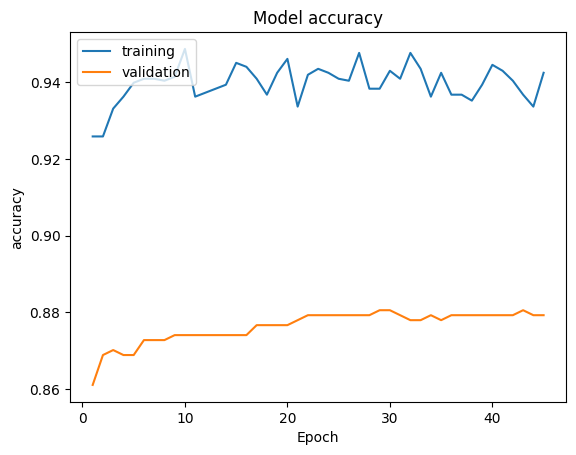

In [32]:
plot_and_save_history(history, checkpoint_dir, metric_name='accuracy')

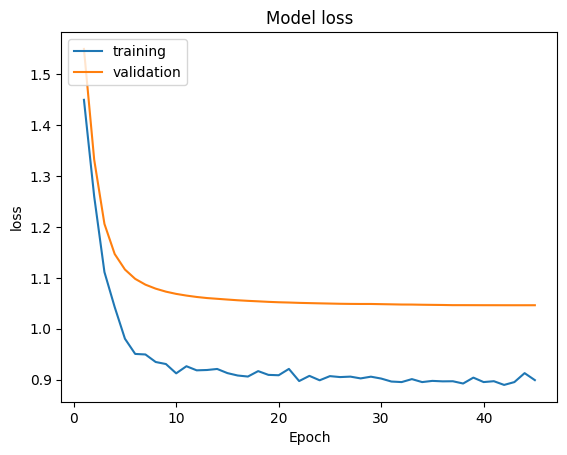

In [33]:
plot_and_save_history(history, checkpoint_dir, metric_name='loss')

In [34]:
train_acc_hist = history.history['accuracy']
val_acc_hist = history.history['val_accuracy']
val_loss_hist = history.history['val_loss']

print(f'Max train_accuracy: {max(train_acc_hist)} in epoch {val_loss_hist.index(min(val_loss_hist))}')
print(f'Min val_loss: {min(val_loss_hist)} in epoch {val_loss_hist.index(min(val_loss_hist))}')
print(f'Max val_accuracy: {max(val_acc_hist)} in epoch {val_acc_hist.index(max(val_acc_hist))}')

Max train_accuracy: 0.9486514329910278 in epoch 42
Min val_loss: 1.0460606813430786 in epoch 42
Max val_accuracy: 0.8805195093154907 in epoch 28


## Evaluate Model

In [35]:
# best_checkpoint_by_loss = str(checkpoint_dir / "best_model_by_loss.keras")
# best_model_by_loss = load_model(best_checkpoint_by_loss)

best_checkpoint_by_acc = str(checkpoint_dir / "best_model_by_acc.keras")
best_model_by_acc = load_model(best_checkpoint_by_acc)

best_model = best_model_by_acc

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 6 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 6 variables whereas the saved optimizer has 260 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has

### Training

In [36]:
from sklearn.metrics import classification_report

train_eval_ds = create_combined_dataset(train_fea_sequences, train_img_sequences, train_labels, training=False, batch_size=BATCH_SIZE)

train_y_pred_vectors = best_model.predict(train_eval_ds)
train_y_pred = np.argmax(train_y_pred_vectors, axis=1)
train_y_true = np.concatenate([y for _, y in train_eval_ds], axis=0)

train_report = classification_report(train_y_true, train_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(train_report)

train_acc = classification_report(train_y_true, train_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

61/61 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step  
              precision    recall  f1-score   support

       Anger     0.9137    0.9621    0.9373       132
     Disgust     0.9645    0.9314    0.9476       204
        Fear     0.9390    0.9524    0.9456       210
   Happiness     1.0000    0.9948    0.9974       382
     Neutral     0.9975    0.9949    0.9962       394
     Sadness     0.9885    0.9885    0.9885       262
    Surprise     0.9826    0.9826    0.9826       344

    accuracy                         0.9782      1928
   macro avg     0.9694    0.9724    0.9707      1928
weighted avg     0.9785    0.9782    0.9783      1928



[[127   4   0   0   0   1   0]
 [  9 190   3   0   0   2   0]
 [  0   3 200   0   1   0   6]
 [  0   0   2 380   0   0   0]
 [  0   0   2   0 392   0   0]
 [  3   0   0   0   0 259   0]
 [  0   0   6   0   0   0 338]]


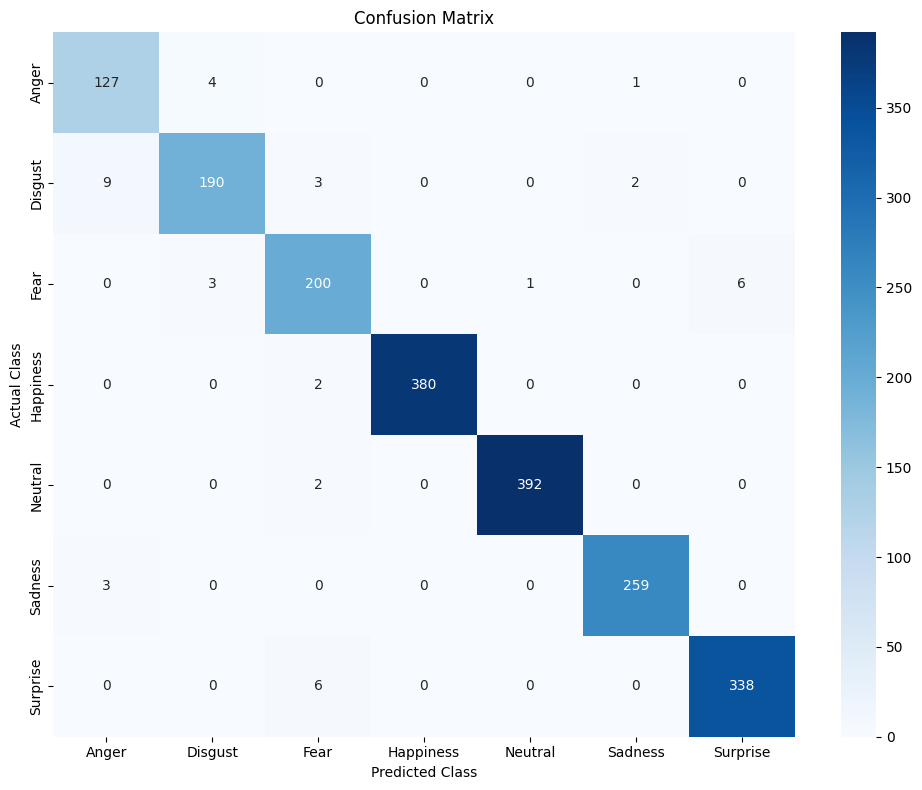

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred):
    class_names = emotion_to_id.keys()

    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

    return fig


train_cm_figure = plot_confusion_matrix(train_y_true, train_y_pred)

### Validation

In [38]:
val_y_pred_vectors = best_model.predict(val_ds)
val_y_pred = np.argmax(val_y_pred_vectors, axis=1)
val_y_true = np.concatenate([y for _, y in val_ds], axis=0)

val_report = classification_report(val_y_true, val_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(val_report)

val_acc = classification_report(val_y_true, val_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step
              precision    recall  f1-score   support

       Anger     0.8830    0.7545    0.8137       110
     Disgust     0.7826    0.8182    0.8000       110
        Fear     0.8878    0.7909    0.8365       110
   Happiness     0.9068    0.9727    0.9386       110
     Neutral     0.9483    1.0000    0.9735       110
     Sadness     0.8333    0.9091    0.8696       110
    Surprise     0.9266    0.9182    0.9224       110

    accuracy                         0.8805       770
   macro avg     0.8812    0.8805    0.8792       770
weighted avg     0.8812    0.8805    0.8792       770



[[ 83  12   0   3   2  10   0]
 [  7  90   2   0   0  10   1]
 [  0   6  87   8   2   0   7]
 [  0   1   0 107   2   0   0]
 [  0   0   0   0 110   0   0]
 [  4   6   0   0   0 100   0]
 [  0   0   9   0   0   0 101]]


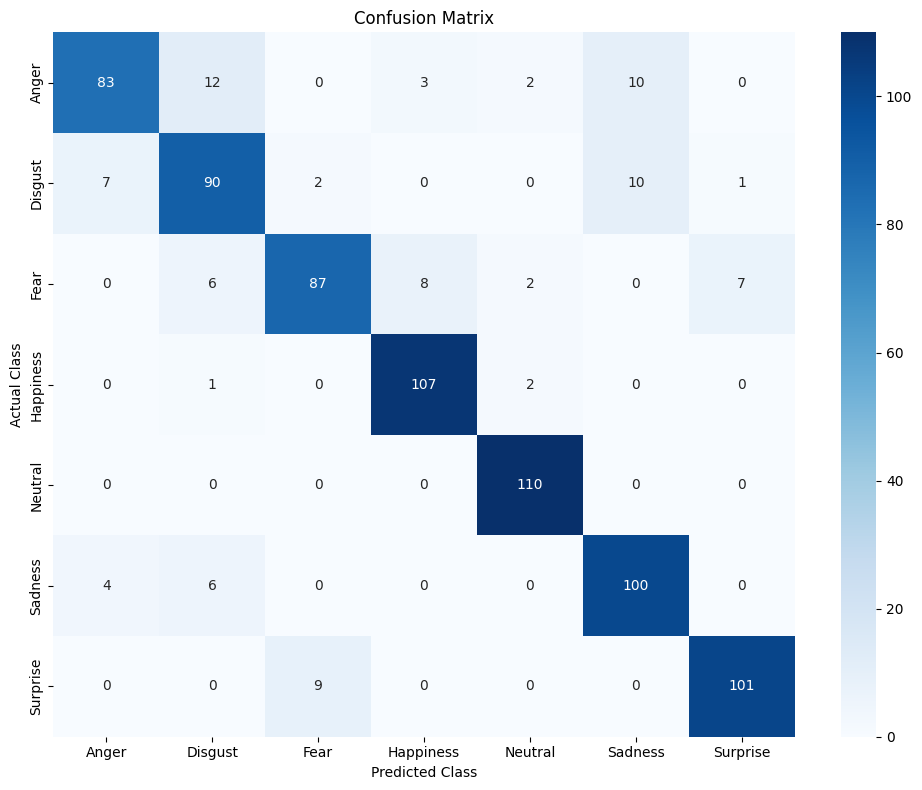

In [39]:
val_cm_figure = plot_confusion_matrix(val_y_true, val_y_pred)

### Test

In [40]:
test_y_pred_vectors = best_model.predict(test_ds)
test_y_pred = np.argmax(test_y_pred_vectors, axis=1)
test_y_true = np.concatenate([y for _, y in test_ds], axis=0)

test_report = classification_report(test_y_true, test_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(test_report)

test_acc = classification_report(test_y_true, test_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 267ms/step
              precision    recall  f1-score   support

       Anger     0.8143    0.5278    0.6404       108
     Disgust     0.5433    0.6389    0.5872       108
        Fear     0.8119    0.7593    0.7847       108
   Happiness     0.7448    1.0000    0.8538       108
     Neutral     0.9364    0.9537    0.9450       108
     Sadness     0.9694    0.8796    0.9223       108
    Surprise     0.9048    0.8796    0.8920       108

    accuracy                         0.8056       756
   macro avg     0.8178    0.8056    0.8036       756
weighted avg     0.8178    0.8056    0.8036       756



[[ 57  45   0   0   5   1   0]
 [  7  69   6  22   0   2   2]
 [  0   6  82  11   1   0   8]
 [  0   0   0 108   0   0   0]
 [  1   0   0   4 103   0   0]
 [  5   7   0   0   1  95   0]
 [  0   0  13   0   0   0  95]]


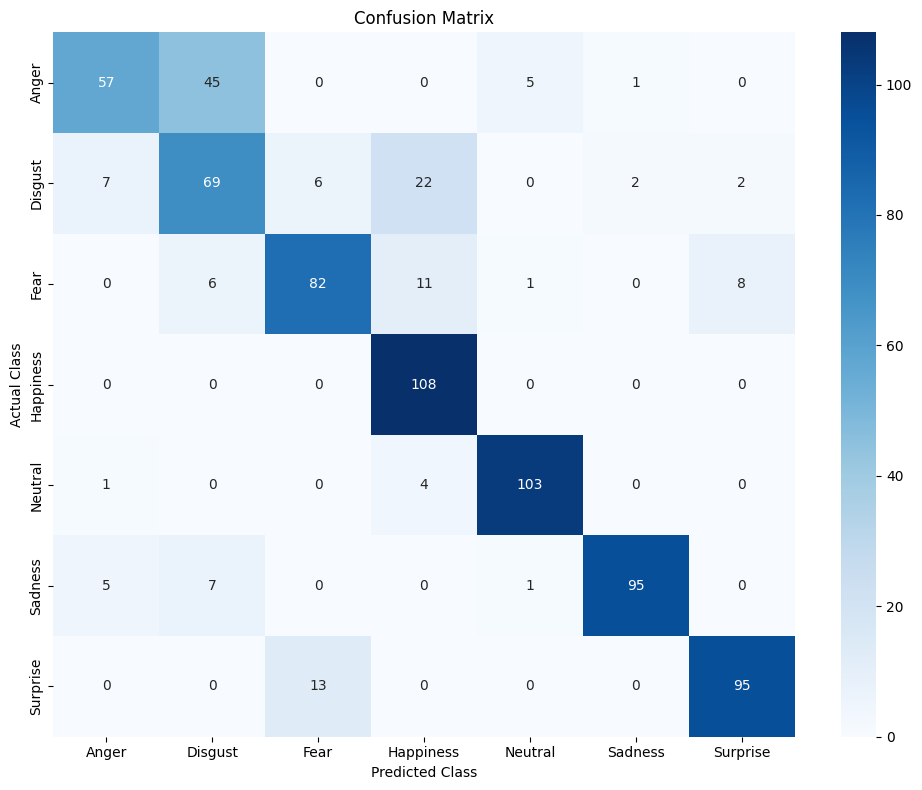

In [41]:
test_cm_figure = plot_confusion_matrix(test_y_true, test_y_pred)

In [42]:
def save_evaluation_results(report, cm_figure, checkpoint_dir):
    with (checkpoint_dir / 'classification_report.txt').open(mode='w') as f:
        f.write(report)
    cm_figure.savefig(str(checkpoint_dir / 'confusion_matrix.png'))


save_evaluation_results(test_report, test_cm_figure, checkpoint_dir)

In [43]:
import time

time.sleep(3)

In [44]:
def add_accuracies_to_checkpoint_dir_name(checkpoint_dir, train_acc, val_acc, test_acc):
    new_name = checkpoint_dir.name + f'_train_{str(train_acc)[2:6]}_val_{str(val_acc)[2:6]}_test_{str(test_acc)[2:6]}'
    new_path = checkpoint_dir.parent / new_name
    checkpoint_dir.rename(new_path)
    return new_path


new_checkpoint_dir = add_accuracies_to_checkpoint_dir_name(checkpoint_dir, train_acc, val_acc, test_acc)

In [45]:
time.sleep(30)

In [46]:
import shutil

shutil.copy2((Path() / name_of_this_notebook), (new_checkpoint_dir / name_of_this_notebook))

PosixPath('20251124-1924-late_fusion_cross_attention-seed-13_train_9782_val_8805_test_8055/late_fusion_cross_attention.ipynb')

###### 